# 🏭 PT yang ada di indonesia
 MMS — Dataset Exploration & Understanding

Notebook ini berisi **Exploratory Data Analysis (EDA)** lengkap dari dataset  
**Manufacturing Dashboard Analytics & Maintenance Management System (MMS)** milik PT Volex.

## Tujuan Notebook
1. **Load & Validate** semua sheet dari file Excel
2. **Profiling Data** — shape, dtype, missing values, unique values
3. **Eksplorasi Visual** — distribusi, tren, korelasi antar variabel
4. **Feature Engineering** — menyiapkan fitur untuk AI model
5. **Insight & Kesimpulan** — temuan penting untuk model prediksi

---
**Dataset:** `PT_Volex_MMS_Production_Dataset (1).xlsx`  
**Periode:** Februari 2026 – Agustus 2026  
**Total Sheet:** 26 tabel

---
## 📦 1. Import Library & Konfigurasi

In [74]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Konfigurasi ───────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Styling plot
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('tab10')

# ── Path Dataset ──────────────────────────────────────────────────────────────
DATASET_PATH = os.path.join('..', 'dataset', 'PT_Volex_MMS_Production_Dataset (1).xlsx')
assert os.path.exists(DATASET_PATH), f'❌ File tidak ditemukan: {DATASET_PATH}'

print('✅ Semua library berhasil di-import!')
print(f'📂 Dataset: {os.path.abspath(DATASET_PATH)}')
print(f'📊 Pandas  : {pd.__version__}')
print(f'🔢 NumPy   : {np.__version__}')

✅ Semua library berhasil di-import!
📂 Dataset: c:\AI\AI untuk Dashboard TA\New folder\dataset\PT_Volex_MMS_Production_Dataset (1).xlsx
📊 Pandas  : 3.0.5
🔢 NumPy   : 2.5.2


---
## 📥 2. Load Semua Sheet Dataset

In [75]:
# Baca seluruh sheet sekaligus ke dalam dictionary
xl = pd.ExcelFile(DATASET_PATH)
ALL_SHEETS = xl.sheet_names

print('📋 Daftar semua sheet:')
for i, s in enumerate(ALL_SHEETS, 1):
    print(f'  {i:>2}. {s}')
print(f'\n📌 Total sheet: {len(ALL_SHEETS)}')

📋 Daftar semua sheet:
   1. README
   2. Data Dictionary
   3. line
   4. machine
   5. process
   6. line_process
   7. shift
   8. technician
   9. pn
  10. sn
  11. data_items
  12. actual_output
  13. machine_status_log
  14. work_order
  15. note
  16. task
  17. work_order_history
  18. notification
  19. cycle_time_machine
  20. troughput_machine
  21. defect_by_process
  22. oee_line
  23. troughput_line
  24. cycle_time_line
  25. availability_line
  26. trend_analysis

📌 Total sheet: 26


In [76]:
# Sheet yang merupakan tabel data (skip README & Data Dictionary)
DATA_SHEETS = [
    'line', 'machine', 'process', 'line_process',
    'shift', 'technician', 'pn', 'sn', 'data_items',
    'actual_output', 'machine_status_log', 'work_order',
    'note', 'task', 'work_order_history', 'notification',
    'cycle_time_machine', 'troughput_machine', 'defect_by_process',
    'oee_line', 'troughput_line', 'cycle_time_line',
    'availability_line', 'trend_analysis'
]

# Load semua tabel
dfs = {}
for sheet in DATA_SHEETS:
    try:
        dfs[sheet] = pd.read_excel(DATASET_PATH, sheet_name=sheet)
        print(f'  ✅ [{sheet}] → {dfs[sheet].shape[0]:>6,} rows × {dfs[sheet].shape[1]:>2} cols')
    except Exception as e:
        print(f'  ⚠️  [{sheet}] gagal: {e}')

print(f'\n✅ Berhasil load {len(dfs)} tabel!')

  ✅ [line] →      4 rows ×  5 cols
  ✅ [machine] →     12 rows ×  7 cols
  ✅ [process] →     12 rows ×  4 cols
  ✅ [line_process] →     12 rows ×  5 cols
  ✅ [shift] →      3 rows ×  5 cols
  ✅ [technician] →      8 rows ×  5 cols
  ✅ [pn] →      8 rows ×  4 cols
  ✅ [sn] → 25,290 rows ×  4 cols
  ✅ [data_items] → 25,290 rows ×  6 cols
  ✅ [actual_output] →  6,340 rows ×  7 cols
  ✅ [machine_status_log] →  1,811 rows ×  9 cols
  ✅ [work_order] →    806 rows × 18 cols
  ✅ [note] →    726 rows ×  5 cols
  ✅ [task] →  2,658 rows ×  5 cols
  ✅ [work_order_history] →    900 rows × 24 cols
  ✅ [notification] →    420 rows × 16 cols
  ✅ [cycle_time_machine] →  6,340 rows ×  9 cols
  ✅ [troughput_machine] →  6,340 rows × 10 cols
  ✅ [defect_by_process] →  6,340 rows × 11 cols
  ✅ [oee_line] →  6,340 rows × 12 cols
  ✅ [troughput_line] →  6,340 rows × 11 cols
  ✅ [cycle_time_line] →  6,340 rows ×  7 cols
  ✅ [availability_line] →  6,340 rows ×  7 cols
  ✅ [trend_analysis] →  6,340 rows × 16 col

In [77]:
# Tampilkan README dataset
readme = pd.read_excel(DATASET_PATH, sheet_name='README', header=None)
print('=' * 70)
print('README DATASET')
print('=' * 70)
for _, row in readme.iterrows():
    val = row.iloc[0]
    if pd.notna(val):
        print(val)

README DATASET
Manufacturing Dashboard Analytics & Maintenance Management System
Synthetic Production Dataset — matched to actual Supabase schema
Purpose:
This is a SYNTHETIC (artificially generated) dataset built to exactly mirror the 24-table
PostgreSQL/Supabase schema of your Manufacturing Dashboard Analytics + Maintenance
Management System (table names, column names, and CHECK-constraint enums match your
schema verbatim). It is meant as a realistic starter dataset for training/testing AI or
ML models (OEE forecasting, downtime/failure prediction, defect classification,
predictive maintenance, anomaly detection) before real production data is available.
IMPORTANT: All values are randomly generated with realistic statistical patterns and
cross-table correlations. They do NOT represent real machines, parts, or production
data from PT Volex Indonesia or any company.
Coverage:
- Period            : 2026-02-01 to 2026-07-31 (6 months)
- Lines             : 4 (Line A-D), each with 3 proce

In [78]:
# Data Dictionary — deskripsi setiap kolom
dd = pd.read_excel(DATASET_PATH, sheet_name='Data Dictionary')
print(f'📖 Data Dictionary: {dd.shape[0]} entri kolom dari {dd["table"].nunique()} tabel\n')
dd.head(20)

📖 Data Dictionary: 212 entri kolom dari 24 tabel



,table,column,description
0,line,id,"uuid, PK"
1,line,name,Production line name (Line A-D)
2,line,status,"Line status, e.g. 'active'"
3,line,total_running_hours,"numeric, cumulative running hours"
4,line,last_active_at,"timestamptz, last time the line was active"
5,machine,id,"uuid, PK"
6,machine,name_machine,Machine display name
7,machine,status,CHECK: active | maintenance | on hold | downti...
8,machine,next_maintenance,"timestamp (no tz), next scheduled maintenance"
9,machine,last_maintenance,"timestamp (no tz), last completed maintenance"


---
## 🔍 3. Profiling Data — Overview Semua Tabel

In [79]:
def profile_table(name: str, df: pd.DataFrame, n_sample: int = 3) -> None:
    """Cetak ringkasan lengkap satu tabel."""
    sep = '─' * 70
    print(f'\n{sep}')
    print(f'  📊 TABEL: {name.upper()}   ({df.shape[0]:,} rows × {df.shape[1]} cols)')
    print(sep)

    # Kolom & tipe data
    info = pd.DataFrame({
        'dtype'       : df.dtypes,
        'non_null'    : df.notna().sum(),
        'null'        : df.isna().sum(),
        'null_%'      : (df.isna().mean() * 100).round(1),
        'unique'      : df.nunique(),
        'sample_value': df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else 'ALL NULL')
    })
    print(info.to_string())

    # Statistik deskriptif kolom numerik
    num_cols = df.select_dtypes(include='number').columns
    if len(num_cols):
        print(f'\n  📈 Statistik Numerik:')
        print(df[num_cols].describe().T.to_string())

    # Sample data
    print(f'\n  🔎 Sample ({n_sample} baris pertama):')
    print(df.head(n_sample).to_string())


# Tampilkan profil untuk semua tabel
for name, df in dfs.items():
    profile_table(name, df)


──────────────────────────────────────────────────────────────────────
  📊 TABEL: LINE   (4 rows × 5 cols)
──────────────────────────────────────────────────────────────────────
                       dtype  non_null  null  null_%  unique                          sample_value
id                       str         4     0  0.0000       4  0a4d2182-cf07-4dc3-b494-5cc84d4e97d9
name                     str         4     0  0.0000       4                                Line A
status                   str         4     0  0.0000       1                                active
total_running_hours  float64         4     0  0.0000       4                             7643.7400
last_active_at           str         4     0  0.0000       4             2026-08-19 02:00:00+00:00

  📈 Statistik Numerik:
                     count      mean      std       min       25%       50%       75%       max
total_running_hours 4.0000 7958.3175 715.8490 7184.2100 7528.8575 7897.6650 8327.1250 8853.7300

  🔎 Sample

---
## 🏗️ 4. Eksplorasi Tabel Master (Referensi)

=== TABEL: line ===
                                  id   name status  total_running_hours            last_active_at
0a4d2182-cf07-4dc3-b494-5cc84d4e97d9 Line A active            7643.7400 2026-08-19 02:00:00+00:00
6dca2598-ddd2-4025-80af-ee4c9cf36923 Line B active            8151.5900 2026-08-19 04:00:00+00:00
5222c79f-4f06-4165-b8f9-4d71e4af4f73 Line C active            7184.2100 2026-08-19 07:00:00+00:00
8fde67f5-e10a-4fbb-afdc-7c209371f874 Line D active            8853.7300 2026-08-19 08:00:00+00:00


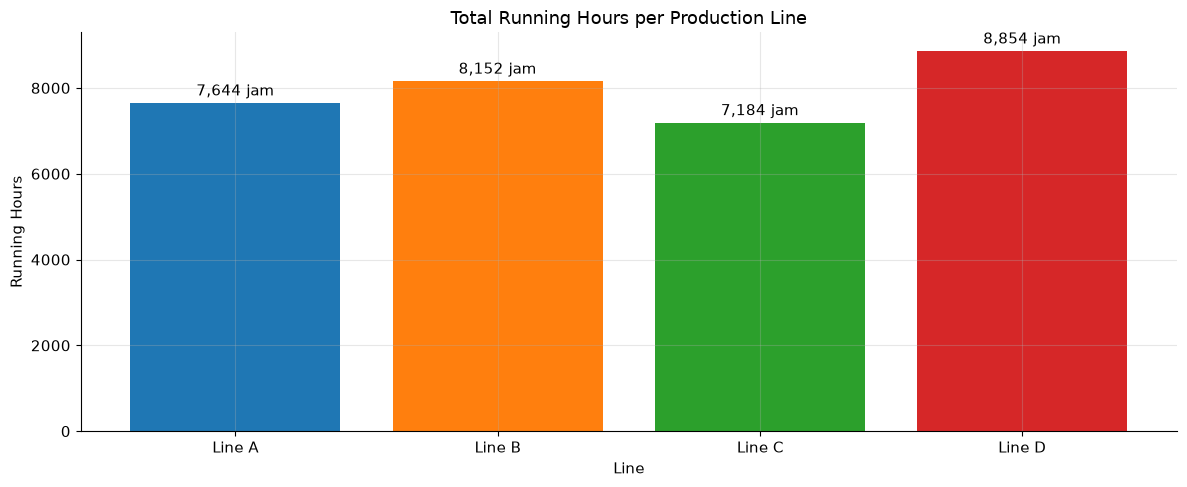

In [80]:
# ── LINE ──────────────────────────────────────────────────────────────────────
line = dfs['line'].copy()
print('=== TABEL: line ===')
print(line.to_string(index=False))

fig, ax = plt.subplots()
bars = ax.bar(line['name'], line['total_running_hours'], color=sns.color_palette('tab10', 4))
ax.bar_label(bars, fmt='{:,.0f} jam', padding=3)
ax.set_title('Total Running Hours per Production Line')
ax.set_xlabel('Line')
ax.set_ylabel('Running Hours')
plt.tight_layout()
plt.show()

=== TABEL: machine ===
              name_machine      status  total_running_hours  total_downtime_hours
      Vision Inspection 01      active            9539.7000               85.6000
Torque Screwdriver Cell 02      active            4764.2000              556.8000
           Wire Bonding 03      active            9961.8000              271.6000
         Assembly Robot 04      active            6877.7000               47.7000
            CNC Milling 05      active            7764.1000              457.3000
Torque Screwdriver Cell 06      active           11663.0000              536.9000
      Injection Molding 07      active            2738.3000              285.4000
      Injection Molding 08    downtime            2274.3000              413.0000
      Packaging Machine 09      active           11626.4000              202.2000
      Conveyor & Sorter 10 maintenance            5899.9000              121.8000
Torque Screwdriver Cell 11      active            5970.6000              14

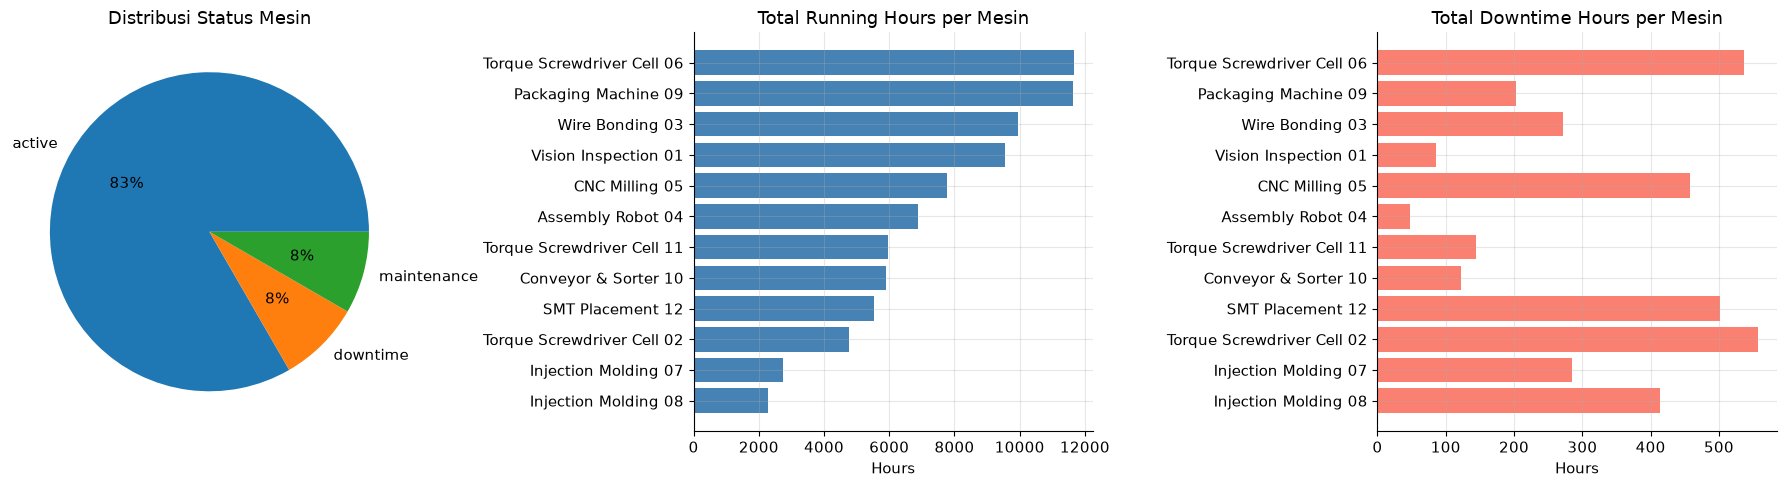


📊 Rasio Downtime per Mesin:
              name_machine  total_running_hours  total_downtime_hours  downtime_ratio_%
      Injection Molding 08            2274.3000              413.0000           18.1600
Torque Screwdriver Cell 02            4764.2000              556.8000           11.6900
      Injection Molding 07            2738.3000              285.4000           10.4200
          SMT Placement 12            5527.2000              501.3000            9.0700
            CNC Milling 05            7764.1000              457.3000            5.8900
Torque Screwdriver Cell 06           11663.0000              536.9000            4.6000
           Wire Bonding 03            9961.8000              271.6000            2.7300
Torque Screwdriver Cell 11            5970.6000              143.9000            2.4100
      Conveyor & Sorter 10            5899.9000              121.8000            2.0600
      Packaging Machine 09           11626.4000              202.2000            1.7400
   

In [81]:
# ── MACHINE ───────────────────────────────────────────────────────────────────
machine = dfs['machine'].copy()
print('=== TABEL: machine ===')
print(machine[['name_machine', 'status', 'total_running_hours', 'total_downtime_hours']].to_string(index=False))

# Status distribusi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

status_counts = machine['status'].value_counts()
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.0f%%',
            colors=sns.color_palette('tab10', len(status_counts)))
axes[0].set_title('Distribusi Status Mesin')

machine_sorted = machine.sort_values('total_running_hours', ascending=True)
axes[1].barh(machine_sorted['name_machine'], machine_sorted['total_running_hours'],
             color='steelblue')
axes[1].set_title('Total Running Hours per Mesin')
axes[1].set_xlabel('Hours')

axes[2].barh(machine_sorted['name_machine'], machine_sorted['total_downtime_hours'],
             color='salmon')
axes[2].set_title('Total Downtime Hours per Mesin')
axes[2].set_xlabel('Hours')

plt.tight_layout()
plt.show()

# Rasio downtime
machine['downtime_ratio_%'] = (machine['total_downtime_hours'] / machine['total_running_hours'] * 100).round(2)
print('\n📊 Rasio Downtime per Mesin:')
print(machine[['name_machine', 'total_running_hours', 'total_downtime_hours', 'downtime_ratio_%']]
      .sort_values('downtime_ratio_%', ascending=False).to_string(index=False))

=== SHIFT ===
shift_name start_time end_time
   Shift 1   06:00:00 14:00:00
   Shift 2   14:00:00 22:00:00
   Shift 3   22:00:00 06:00:00

=== TECHNICIAN ===
            name          specialization  is_active
     Umi Hidayat                Robotics       True
    Gita Pratama              Mechanical       True
Hendra Kurniawan              Mechanical       True
  Hendra Pratama Hydraulics & Pneumatics       True
Indah Firmansyah         SMT/Electronics       True
   Lukman Wijaya            PLC/Controls       True
  Lukman Santoso         SMT/Electronics       True
   Indah Pratama                Robotics       True


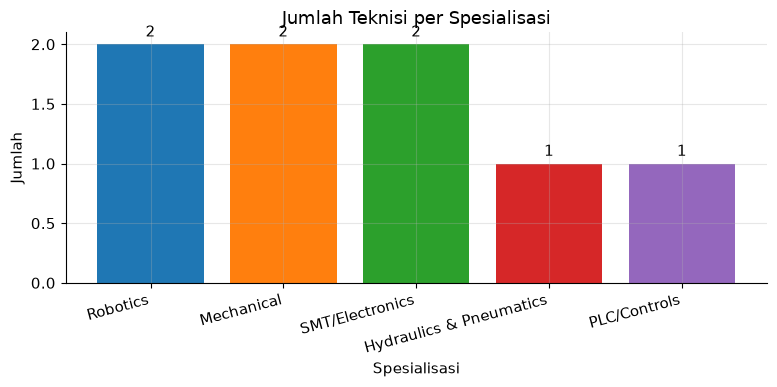

In [82]:
# ── SHIFT & TECHNICIAN ────────────────────────────────────────────────────────
shift     = dfs['shift'].copy()
technician = dfs['technician'].copy()

print('=== SHIFT ===')
print(shift[['shift_name', 'start_time', 'end_time']].to_string(index=False))

print('\n=== TECHNICIAN ===')
print(technician[['name', 'specialization', 'is_active']].to_string(index=False))

# Visualisasi spesialisasi teknisi
spec_counts = technician['specialization'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(spec_counts.index, spec_counts.values, color=sns.color_palette('tab10', len(spec_counts)))
ax.bar_label(bars, padding=3)
ax.set_title('Jumlah Teknisi per Spesialisasi')
ax.set_xlabel('Spesialisasi')
ax.set_ylabel('Jumlah')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 📦 5. Eksplorasi Data Produksi

=== ACTUAL OUTPUT ===
  Jumlah record : 6,340
  Periode       : 2026-02-01 s/d 2026-08-01
  Target output : 1000 (konstan)
  Avg actual    : 874.9 unit
  Avg achieve%  : 87.5%
  Min output    : 455
  Max output    : 1,050


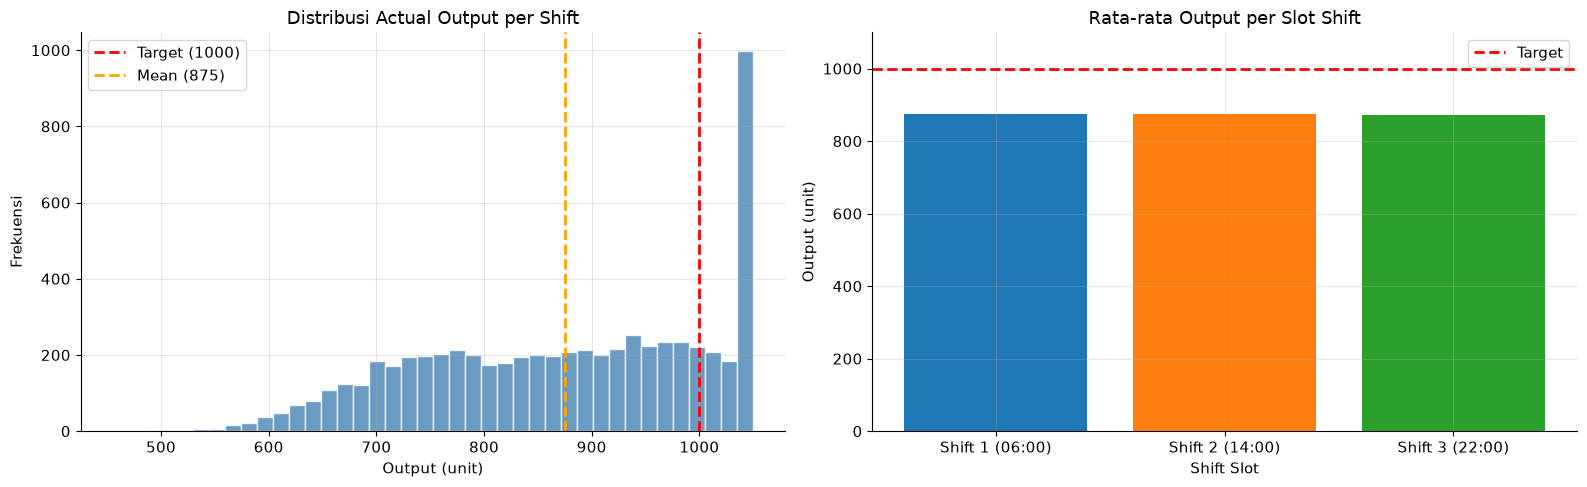

In [83]:
# ── ACTUAL OUTPUT ─────────────────────────────────────────────────────────────
ao = dfs['actual_output'].copy()
ao['created_at'] = pd.to_datetime(ao['created_at'], utc=True)
ao['date']       = ao['created_at'].dt.date
ao['achievement_%'] = (ao['output'] / ao['target_output'] * 100).round(2)

print('=== ACTUAL OUTPUT ===')
print(f'  Jumlah record : {ao.shape[0]:,}')
print(f'  Periode       : {ao["date"].min()} s/d {ao["date"].max()}')
print(f'  Target output : {ao["target_output"].iloc[0]} (konstan)')
print(f'  Avg actual    : {ao["output"].mean():,.1f} unit')
print(f'  Avg achieve%  : {ao["achievement_%"].mean():.1f}%')
print(f'  Min output    : {ao["output"].min():,}')
print(f'  Max output    : {ao["output"].max():,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi output
axes[0].hist(ao['output'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(ao['target_output'].iloc[0], color='red', linestyle='--', linewidth=2, label='Target (1000)')
axes[0].axvline(ao['output'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean ({ao["output"].mean():.0f})')
axes[0].set_title('Distribusi Actual Output per Shift')
axes[0].set_xlabel('Output (unit)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Output per shift slot
shift_avg = ao.groupby('hour_slot')['output'].mean().reset_index()
axes[1].bar(shift_avg['hour_slot'], shift_avg['output'], color=sns.color_palette('tab10', 3))
axes[1].axhline(1000, color='red', linestyle='--', linewidth=2, label='Target')
axes[1].set_title('Rata-rata Output per Slot Shift')
axes[1].set_xlabel('Shift Slot')
axes[1].set_ylabel('Output (unit)')
axes[1].set_ylim(0, 1100)
axes[1].legend()

plt.tight_layout()
plt.show()

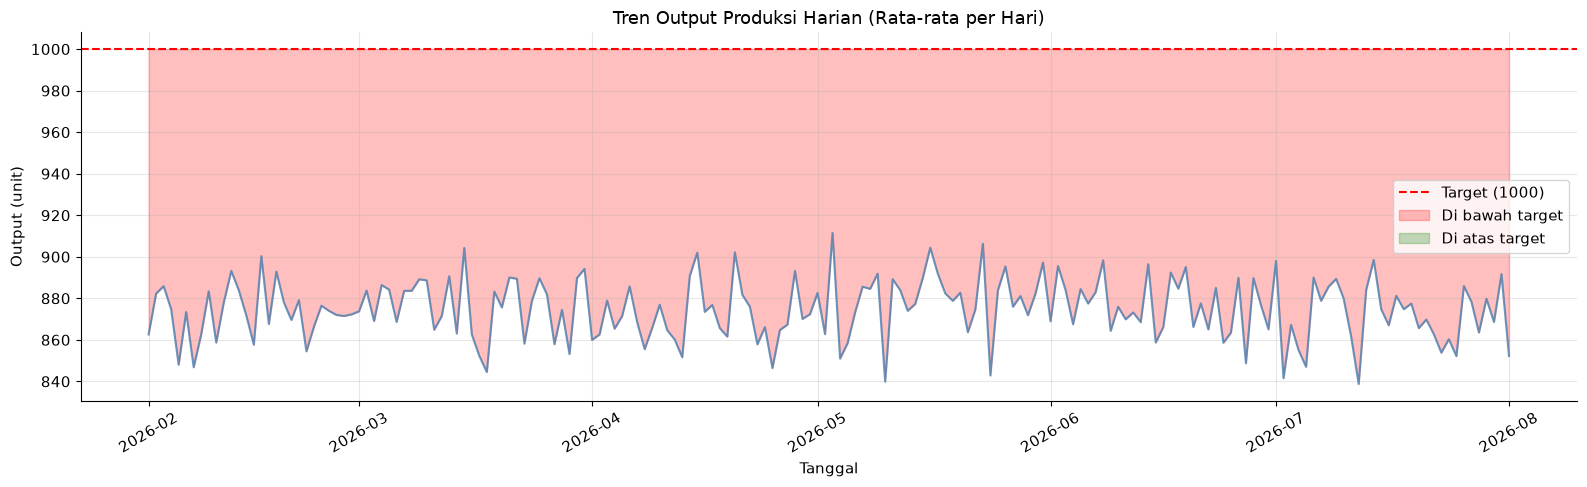

In [84]:
# Tren output harian
daily_output = ao.groupby('date')['output'].mean().reset_index()
daily_output['date'] = pd.to_datetime(daily_output['date'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_output['date'], daily_output['output'],
        color='steelblue', linewidth=1.5, alpha=0.8)
ax.axhline(1000, color='red', linestyle='--', linewidth=1.5, label='Target (1000)')
ax.fill_between(daily_output['date'], daily_output['output'], 1000,
                where=daily_output['output'] < 1000,
                alpha=0.25, color='red', label='Di bawah target')
ax.fill_between(daily_output['date'], daily_output['output'], 1000,
                where=daily_output['output'] >= 1000,
                alpha=0.25, color='green', label='Di atas target')
ax.set_title('Tren Output Produksi Harian (Rata-rata per Hari)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Output (unit)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

=== SERIAL NUMBERS (sn) ===
  Total SN        : 25,290
  Unique SN       : 25,288
  Distribusi per Part Number:
part_number  jumlah_sn
    PN-A-01       3164
    PN-A-02       3122
    PN-B-01       3131
    PN-B-02       3150
    PN-C-01       3183
    PN-C-02       3144
    PN-D-01       3214
    PN-D-02       3182

=== DATA ITEMS STATUS ===
status
pass      24284
reject     1006
  Pass Rate: 96.02%


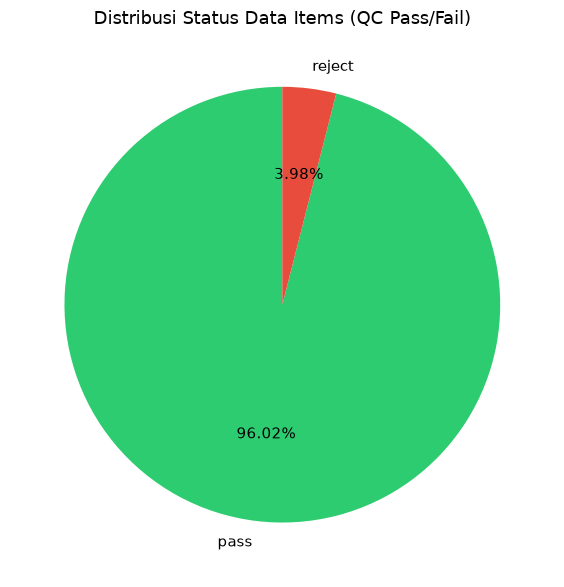

In [85]:
# ── SERIAL NUMBER & DATA ITEMS ────────────────────────────────────────────────
sn         = dfs['sn'].copy()
data_items = dfs['data_items'].copy()

print('=== SERIAL NUMBERS (sn) ===')
print(f'  Total SN        : {sn.shape[0]:,}')
print(f'  Unique SN       : {sn["serial_number"].nunique():,}')
print(f'  Distribusi per Part Number:')

pn = dfs['pn'].copy()
sn_pn = sn.merge(pn[['id', 'part_number']], left_on='part_number_id', right_on='id', how='left')
print(sn_pn.groupby('part_number').size().reset_index(name='jumlah_sn').to_string(index=False))

print('\n=== DATA ITEMS STATUS ===')
status_counts = data_items['status'].value_counts()
print(status_counts.to_string())
print(f'  Pass Rate: {(status_counts.get("pass", 0) / data_items.shape[0] * 100):.2f}%')

# Pie chart status
fig, ax = plt.subplots(figsize=(6, 6))
colors_status = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
ax.pie(status_counts.values, labels=status_counts.index,
       autopct='%1.2f%%', colors=colors_status[:len(status_counts)],
       startangle=90)
ax.set_title('Distribusi Status Data Items (QC Pass/Fail)')
plt.tight_layout()
plt.show()

---
## 🔧 6. Eksplorasi Maintenance & Machine Status

=== MACHINE STATUS LOG ===
  Total log      : 1,811
  Distribusi status:
status
active         911
downtime       423
maintenance    256
on hold        152
inactive        69


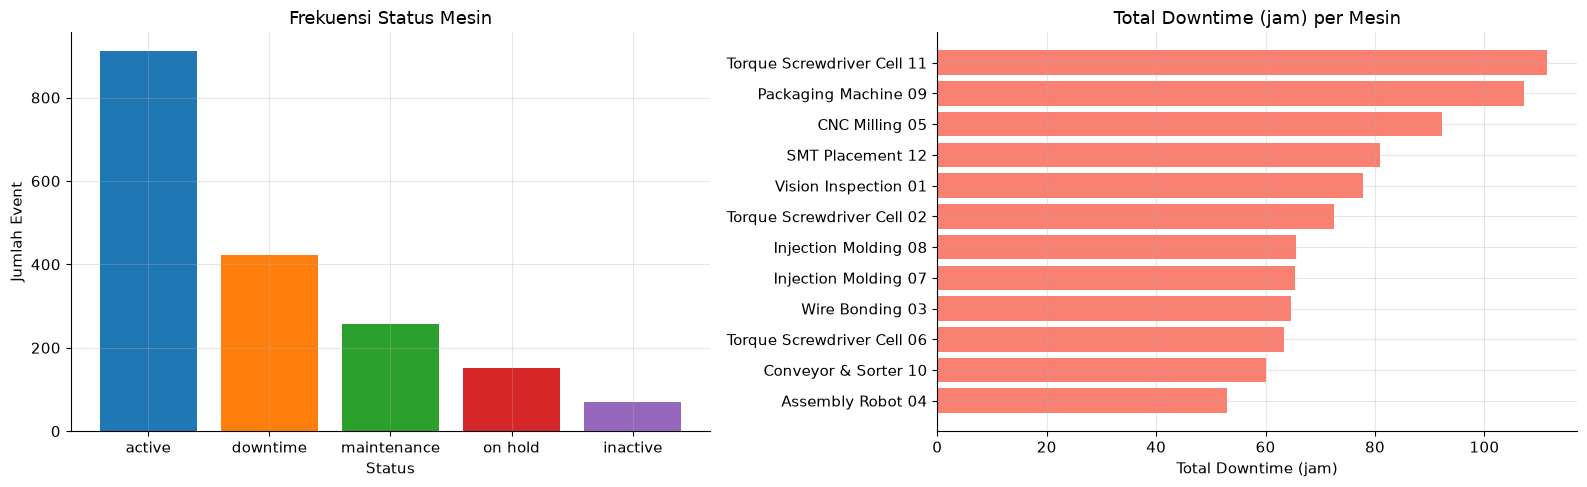


📊 Statistik Durasi per Status (jam):
             count    mean  median    min      max
status                                            
active         911 54.9400 38.7000 2.0000 240.0000
downtime       423  2.1600  2.0800 0.2700   3.9700
inactive        69  4.5300  4.7300 0.0300   7.9700
maintenance    256  2.8300  2.7900 0.5000   4.9800
on hold        152  0.8500  0.8500 0.1700   1.4800


In [86]:
# ── MACHINE STATUS LOG ────────────────────────────────────────────────────────
msl = dfs['machine_status_log'].copy()
msl['start_time'] = pd.to_datetime(msl['start_time'], utc=True)
msl['end_time']   = pd.to_datetime(msl['end_time'],   utc=True)
msl['duration_hours'] = msl['duration_seconds'] / 3600

print('=== MACHINE STATUS LOG ===')
print(f'  Total log      : {msl.shape[0]:,}')
print(f'  Distribusi status:') 
print(msl['status'].value_counts().to_string())

# Merge dengan machine name
msl_m = msl.merge(machine[['id', 'name_machine']], left_on='machine_id', right_on='id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi status
sc = msl['status'].value_counts()
axes[0].bar(sc.index, sc.values, color=sns.color_palette('tab10', len(sc)))
axes[0].set_title('Frekuensi Status Mesin')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Event')

# Total downtime per mesin
downtime_per_machine = (
    msl_m[msl_m['status'] == 'downtime']
    .groupby('name_machine')['duration_hours']
    .sum()
    .sort_values(ascending=True)
)
axes[1].barh(downtime_per_machine.index, downtime_per_machine.values, color='salmon')
axes[1].set_title('Total Downtime (jam) per Mesin')
axes[1].set_xlabel('Total Downtime (jam)')

plt.tight_layout()
plt.show()

print('\n📊 Statistik Durasi per Status (jam):')
print(msl_m.groupby('status')['duration_hours']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2).to_string())

=== WORK ORDER ===
  Total WO       : 806
  Distribusi Type:
type
Corrective    516
Preventive    290

  Distribusi Priority:
priority
Medium      288
Low         211
High        170
Critical    137

  Distribusi Status:
status
Completed      732
In Progress     42
Pending         32


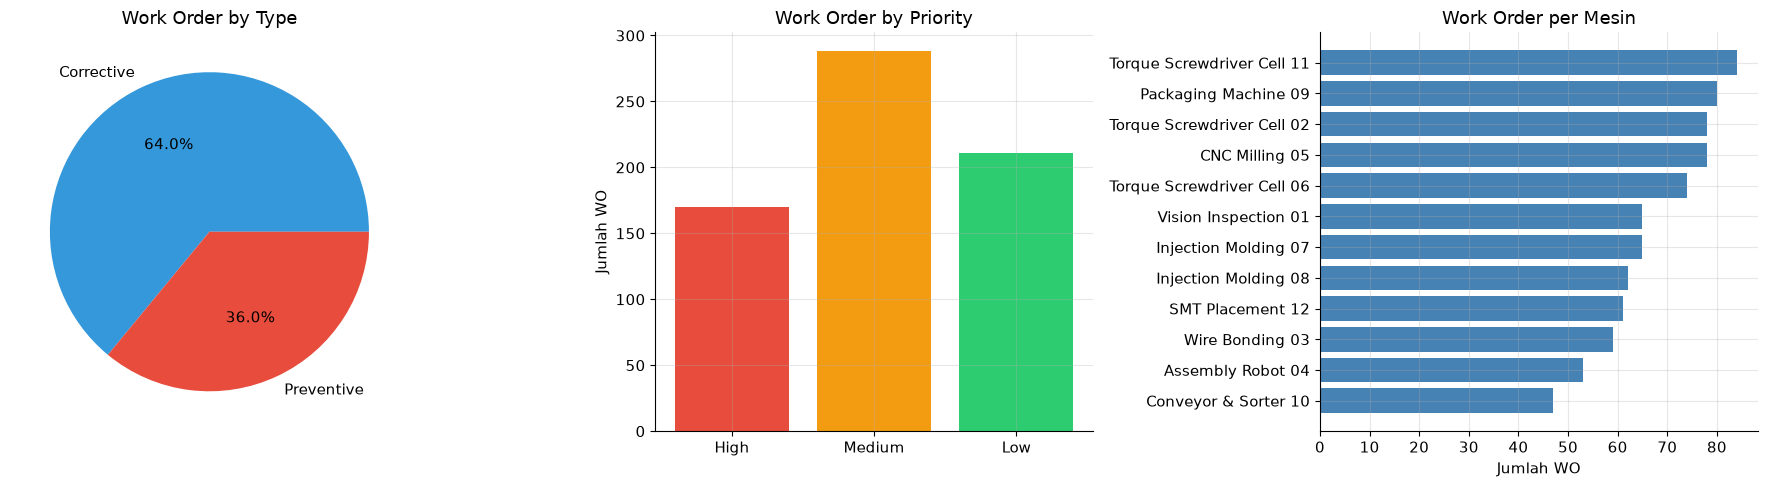


⏱️  Work Order yang Sudah Selesai: 732 WO
  Estimated avg : 3.20 jam
  Actual avg    : 2.42 jam
  Selisih avg   : -0.78 jam (+ = lebih lama)


In [87]:
# ── WORK ORDER ────────────────────────────────────────────────────────────────
wo = dfs['work_order'].copy()
wo['created_at']   = pd.to_datetime(wo['created_at'])
wo['completed_at'] = pd.to_datetime(wo['completed_at'])

print('=== WORK ORDER ===')
print(f'  Total WO       : {wo.shape[0]:,}')
print(f'  Distribusi Type:')
print(wo['type'].value_counts().to_string())
print(f'\n  Distribusi Priority:')
print(wo['priority'].value_counts().to_string())
print(f'\n  Distribusi Status:')
print(wo['status'].value_counts().to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# WO per Type
wt = wo['type'].value_counts()
axes[0].pie(wt, labels=wt.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'])
axes[0].set_title('Work Order by Type')

# WO per Priority
priority_order = ['High', 'Medium', 'Low']
wp = wo['priority'].value_counts().reindex(priority_order)
axes[1].bar(wp.index, wp.values, color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('Work Order by Priority')
axes[1].set_ylabel('Jumlah WO')

# WO per Machine
wo_machine = wo.groupby('machine_name').size().sort_values(ascending=True)
axes[2].barh(wo_machine.index, wo_machine.values, color='steelblue')
axes[2].set_title('Work Order per Mesin')
axes[2].set_xlabel('Jumlah WO')

plt.tight_layout()
plt.show()

# Analisis durasi WO (Estimated vs Actual)
def parse_duration_hr(s):
    """Ekstrak angka jam dari string seperti '2.5 hr'."""
    try:
        return float(str(s).split()[0])
    except:
        return np.nan

wo['est_hr']    = wo['estimated_duration'].apply(parse_duration_hr)
wo['actual_hr'] = wo['actual_duration'].apply(parse_duration_hr)
wo['duration_diff_hr'] = wo['actual_hr'] - wo['est_hr']

completed_wo = wo.dropna(subset=['actual_hr'])
print(f'\n⏱️  Work Order yang Sudah Selesai: {completed_wo.shape[0]} WO')
print(f'  Estimated avg : {completed_wo["est_hr"].mean():.2f} jam')
print(f'  Actual avg    : {completed_wo["actual_hr"].mean():.2f} jam')
print(f'  Selisih avg   : {completed_wo["duration_diff_hr"].mean():.2f} jam (+ = lebih lama)')

---
## 📈 7. Eksplorasi OEE & Metrik Kinerja

=== OEE LINE ===
  Total record   : 6,340
       oee_line  availability  perfomance   quality
count 6340.0000     6340.0000   6340.0000 6340.0000
mean     0.6600        0.9662      0.7128    0.9603
std      0.2477        0.0643      0.2521    0.1083
min      0.0000        0.5420      0.1477    0.0000
25%      0.4476        0.9572      0.4952    1.0000
50%      0.6756        1.0000      0.7451    1.0000
75%      0.8819        1.0000      1.0000    1.0000
max      1.0000        1.0000      1.0000    1.0000


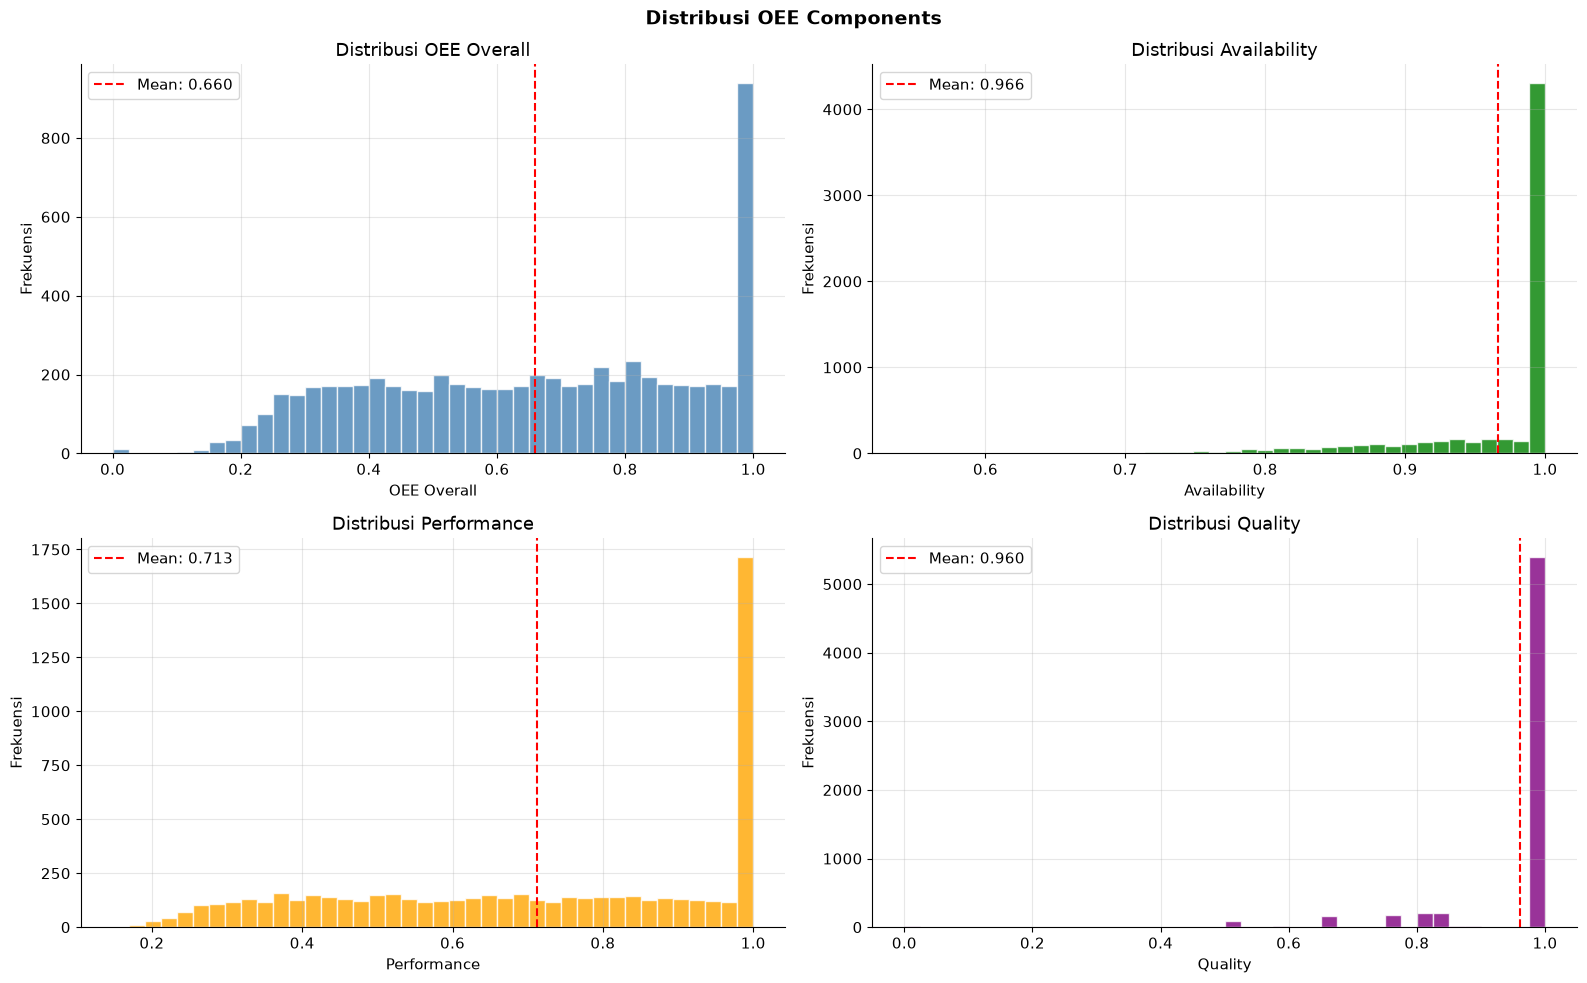

In [88]:
# ── OEE LINE ──────────────────────────────────────────────────────────────────
oee = dfs['oee_line'].copy()
oee['created_at'] = pd.to_datetime(oee['created_at'], utc=True)
oee['date'] = oee['created_at'].dt.date

print('=== OEE LINE ===')
print(f'  Total record   : {oee.shape[0]:,}')
oee_stats = oee[['oee_line', 'availability', 'perfomance', 'quality']].describe()
print(oee_stats.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = {
    'oee_line'    : ('OEE Overall', 'steelblue'),
    'availability': ('Availability', 'green'),
    'perfomance'  : ('Performance', 'orange'),
    'quality'     : ('Quality', 'purple')
}

for ax, (col, (label, color)) in zip(axes.flat, metrics.items()):
    ax.hist(oee[col], bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(oee[col].mean(), color='red', linestyle='--',
               label=f'Mean: {oee[col].mean():.3f}')
    ax.set_title(f'Distribusi {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi OEE Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

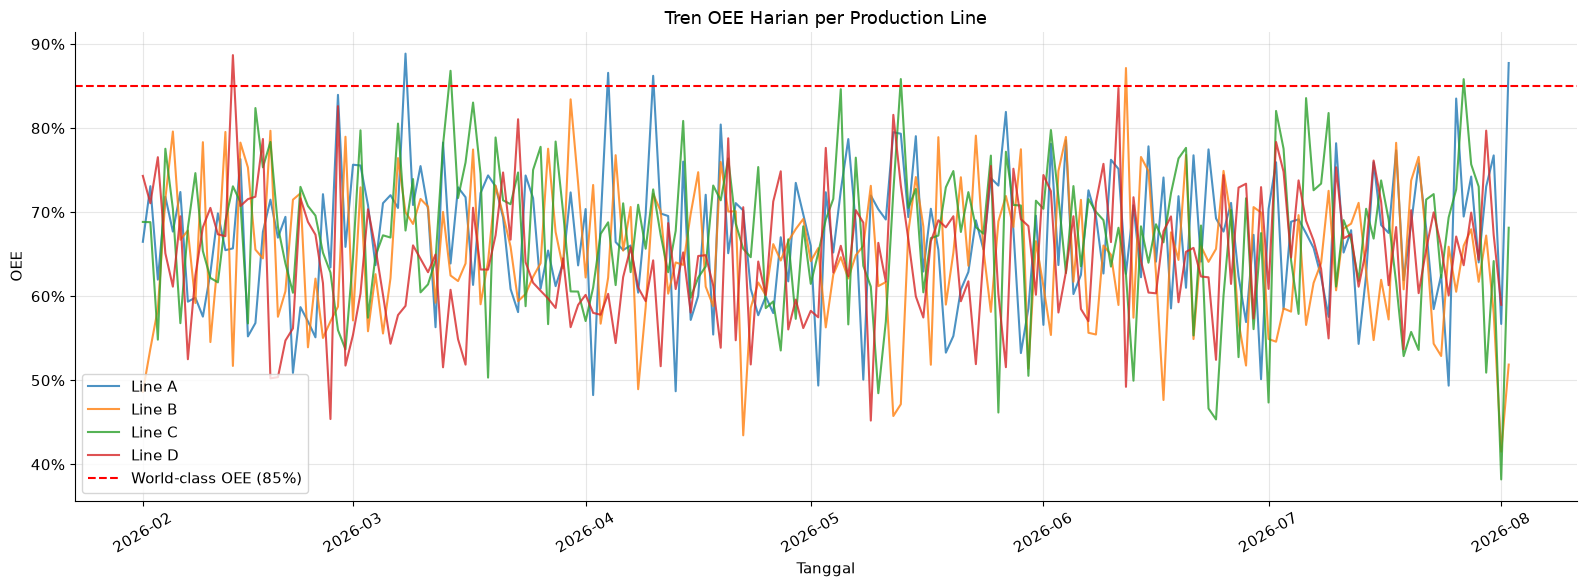


📊 Rata-rata OEE per Line:
           oee_line  availability  perfomance  quality
line_name                                             
Line A       0.6720        0.9674      0.7243   0.9600
Line B       0.6498        0.9643      0.7023   0.9615
Line C       0.6729        0.9657      0.7260   0.9623
Line D       0.6453        0.9676      0.6990   0.9574


In [89]:
# Tren OEE harian per line
line_map = dfs['line'].set_index('id')['name'].to_dict()
oee['line_name'] = oee['line_id'].map(line_map)

oee_daily = (
    oee.groupby(['date', 'line_name'])[['oee_line', 'availability', 'perfomance', 'quality']]
    .mean()
    .reset_index()
)
oee_daily['date'] = pd.to_datetime(oee_daily['date'])

fig, ax = plt.subplots(figsize=(16, 6))
for line_name, grp in oee_daily.groupby('line_name'):
    ax.plot(grp['date'], grp['oee_line'], label=line_name, linewidth=1.5, alpha=0.8)

ax.axhline(0.85, color='red', linestyle='--', linewidth=1.5, label='World-class OEE (85%)')
ax.set_title('Tren OEE Harian per Production Line')
ax.set_xlabel('Tanggal')
ax.set_ylabel('OEE')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('\n📊 Rata-rata OEE per Line:')
print(oee.groupby('line_name')[['oee_line', 'availability', 'perfomance', 'quality']]
      .mean().round(4).to_string())

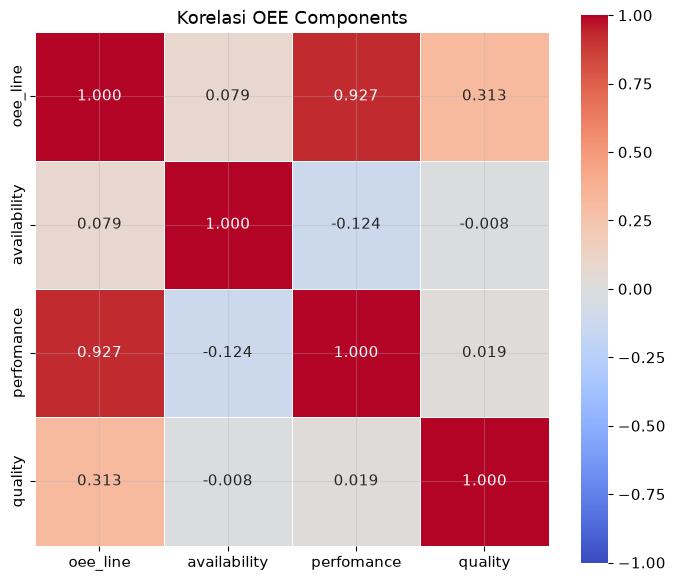

              oee_line  availability  perfomance  quality
oee_line        1.0000        0.0786      0.9266   0.3134
availability    0.0786        1.0000     -0.1237  -0.0085
perfomance      0.9266       -0.1237      1.0000   0.0190
quality         0.3134       -0.0085      0.0190   1.0000


In [90]:
# Korelasi OEE components
oee_corr = oee[['oee_line', 'availability', 'perfomance', 'quality']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(oee_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Korelasi OEE Components')
plt.tight_layout()
plt.show()

print(oee_corr.round(4).to_string())

---
## ⚙️ 8. Eksplorasi Throughput & Cycle Time

=== THROUGHPUT MACHINE ===
       troughput  total_pass  interval_time
count  6340.0000   6340.0000      6340.0000
mean    113.8000      3.8200     27827.9500
std      19.6300      1.5000      1853.2600
min      56.8800      0.0000     15609.0000
25%      98.5900      3.0000     27566.2500
50%     114.7500      4.0000     28800.0000
75%     128.6200      5.0000     28800.0000
max     229.3700     10.0000     28800.0000


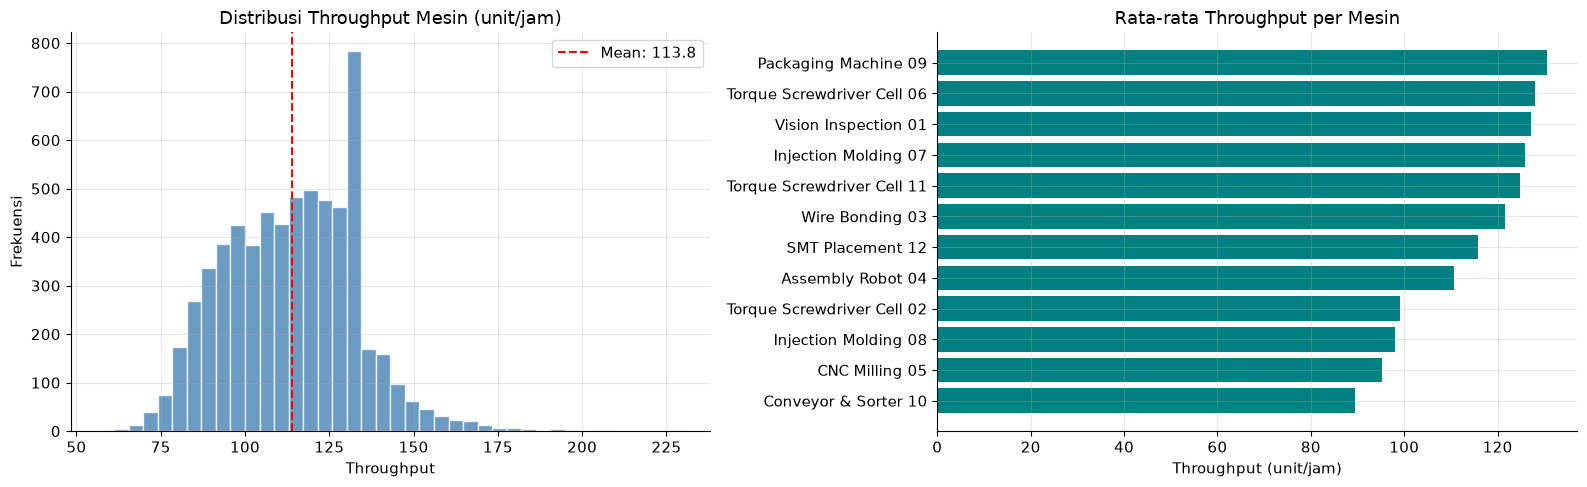

In [91]:
# ── THROUGHPUT MACHINE ────────────────────────────────────────────────────────
tp_m = dfs['troughput_machine'].copy()
tp_m['created_at'] = pd.to_datetime(tp_m['created_at'], utc=True)

machine_map = machine.set_index('id')['name_machine'].to_dict()
tp_m['machine_name'] = tp_m['machine_id'].map(machine_map)

print('=== THROUGHPUT MACHINE ===')
print(tp_m[['troughput', 'total_pass', 'interval_time']].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi throughput
axes[0].hist(tp_m['troughput'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(tp_m['troughput'].mean(), color='red', linestyle='--',
                label=f'Mean: {tp_m["troughput"].mean():.1f}')
axes[0].set_title('Distribusi Throughput Mesin (unit/jam)')
axes[0].set_xlabel('Throughput')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Avg throughput per mesin
tp_avg = tp_m.groupby('machine_name')['troughput'].mean().sort_values(ascending=True)
axes[1].barh(tp_avg.index, tp_avg.values, color='teal')
axes[1].set_title('Rata-rata Throughput per Mesin')
axes[1].set_xlabel('Throughput (unit/jam)')

plt.tight_layout()
plt.show()

=== CYCLE TIME MACHINE ===
       total_output  actual_cycle_time
count     6340.0000          6340.0000
mean       874.8600            28.3100
std        132.2100            11.1600
min        455.0000             8.2000
25%        767.0000            18.8200
50%        888.0000            28.0300
75%        992.0000            37.5300
max       1050.0000            53.9100


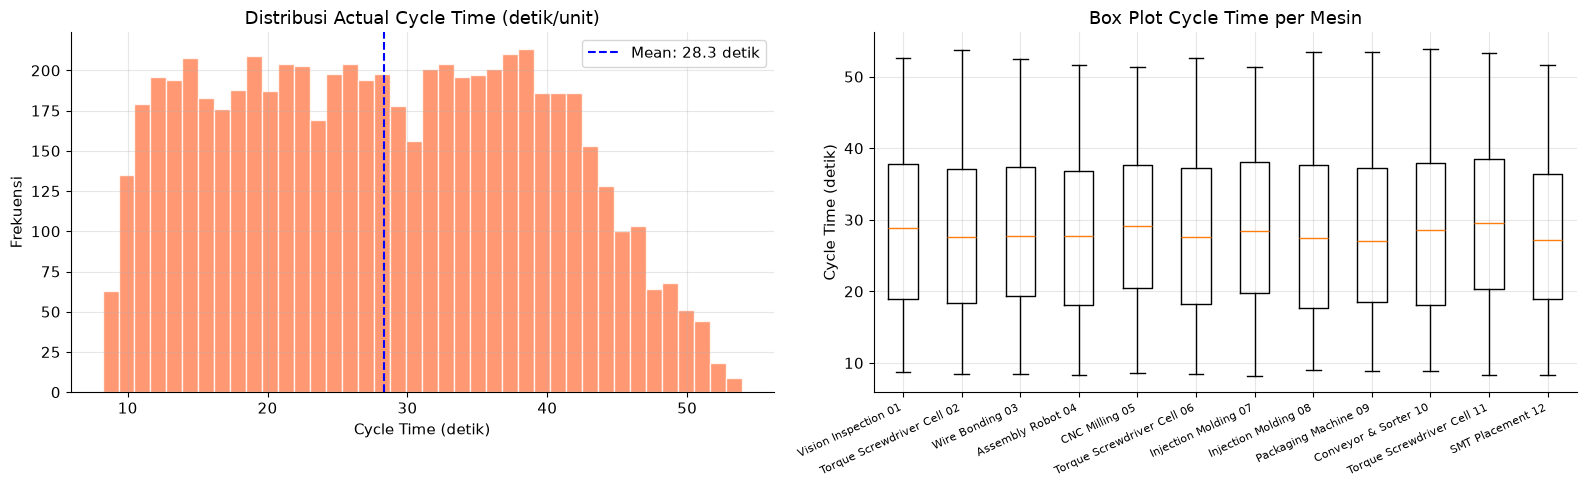

In [92]:
# ── CYCLE TIME MACHINE ────────────────────────────────────────────────────────
ct_m = dfs['cycle_time_machine'].copy()
ct_m['created_at']  = pd.to_datetime(ct_m['created_at'], utc=True)
ct_m['machine_name'] = ct_m['machine_id'].map(machine_map)

print('=== CYCLE TIME MACHINE ===')
print(ct_m[['total_output', 'actual_cycle_time']].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi cycle time
axes[0].hist(ct_m['actual_cycle_time'], bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[0].axvline(ct_m['actual_cycle_time'].mean(), color='blue', linestyle='--',
                label=f'Mean: {ct_m["actual_cycle_time"].mean():.1f} detik')
axes[0].set_title('Distribusi Actual Cycle Time (detik/unit)')
axes[0].set_xlabel('Cycle Time (detik)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Box plot cycle time per mesin
ct_by_machine = [ct_m[ct_m['machine_name'] == m]['actual_cycle_time'].dropna()
                 for m in machine['name_machine']]
axes[1].boxplot(ct_by_machine, tick_labels=machine['name_machine'], vert=True)
axes[1].set_title('Box Plot Cycle Time per Mesin')
axes[1].set_ylabel('Cycle Time (detik)')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔴 9. Eksplorasi Defect & Quality

=== DEFECT BY PROCESS ===
  Total record  : 6,340
  Avg reject    : 0.158 unit/shift
  Avg reject%   : 3.97%


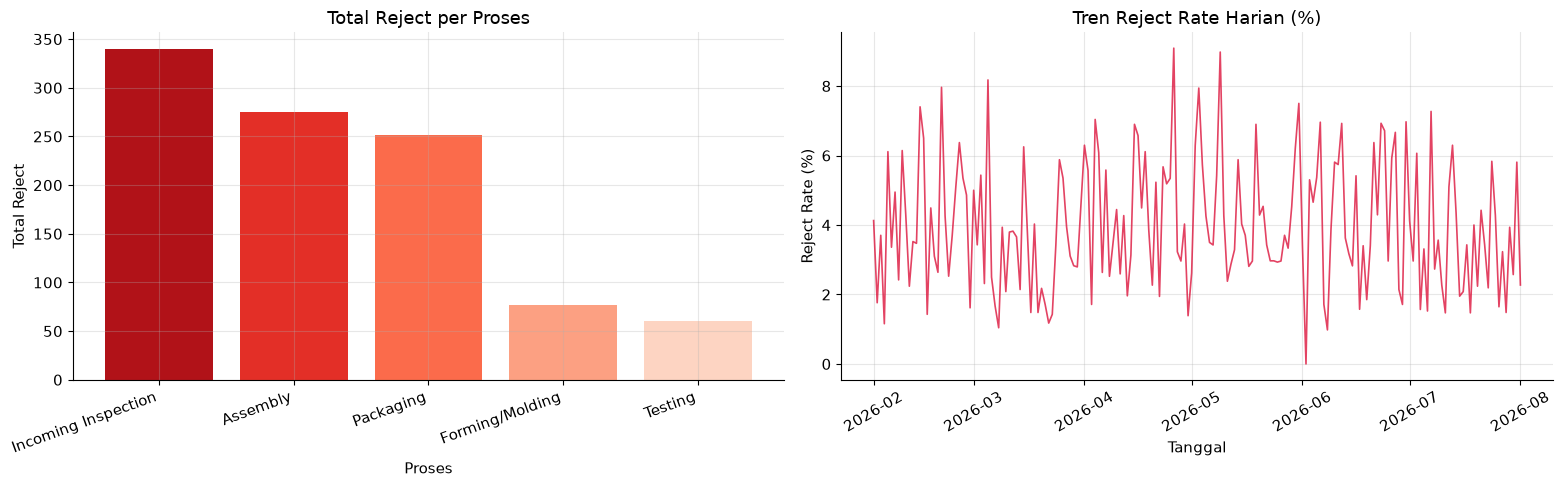

In [93]:
# ── DEFECT BY PROCESS ─────────────────────────────────────────────────────────
defect = dfs['defect_by_process'].copy()
defect['recorded_date'] = pd.to_datetime(defect['recorded_date'])

process_map = dfs['process'].set_index('id')['name'].to_dict()
line_process_map = dfs['line_process'].set_index('id')
line_process_map['process_name'] = line_process_map['process_id'].map(process_map)
line_process_map['line_name']    = line_process_map['line_id'].map(line_map)
lp_map = line_process_map['process_name'].to_dict()

defect['process_name'] = defect['line_process_id'].map(lp_map)
defect['reject_rate']  = defect['total_reject'] / defect['total_produced'].replace(0, np.nan)

print('=== DEFECT BY PROCESS ===')
print(f'  Total record  : {defect.shape[0]:,}')
print(f'  Avg reject    : {defect["total_reject"].mean():.3f} unit/shift')
print(f'  Avg reject%   : {defect["reject_rate"].mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Reject per proses
reject_by_proc = defect.groupby('process_name')['total_reject'].sum().sort_values(ascending=False)
axes[0].bar(reject_by_proc.index, reject_by_proc.values,
            color=sns.color_palette('Reds_r', len(reject_by_proc)))
axes[0].set_title('Total Reject per Proses')
axes[0].set_xlabel('Proses')
axes[0].set_ylabel('Total Reject')
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

# Reject rate harian
daily_reject = defect.groupby('recorded_date')['reject_rate'].mean().reset_index()
axes[1].plot(daily_reject['recorded_date'], daily_reject['reject_rate'] * 100,
             color='crimson', linewidth=1.2, alpha=0.8)
axes[1].set_title('Tren Reject Rate Harian (%)')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Reject Rate (%)')
plt.setp(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

---
## 📊 10. Trend Analysis — Dataset Utama AI

In [94]:
# ── TREND ANALYSIS ────────────────────────────────────────────────────────────
trend = dfs['trend_analysis'].copy()
trend['recorded_date'] = pd.to_datetime(trend['recorded_date'])
trend['line_name']     = trend['line_id'].map(line_map)
trend['downtime_hours'] = trend['total_downtime_seconds'] / 3600
trend['downtime_rate']  = trend['total_downtime_seconds'] / trend['planned_time_seconds']

print('=== TREND ANALYSIS ===')
print(f'  Total record   : {trend.shape[0]:,}')
print(f'  Periode        : {trend["recorded_date"].min()} s/d {trend["recorded_date"].max()}')
print('\n  Statistik deskriptif:')
print(trend[['total_output', 'total_pass', 'total_reject',
             'quality_rate', 'efficiency', 'downtime_hours', 'downtime_count']]
      .describe().round(3).to_string())

=== TREND ANALYSIS ===
  Total record   : 6,340
  Periode        : 2026-02-01 00:00:00 s/d 2026-08-01 00:00:00

  Statistik deskriptif:
       total_output  total_pass  total_reject  quality_rate  efficiency  downtime_hours  downtime_count
count     6340.0000   6340.0000     6340.0000     6340.0000   6340.0000       6340.0000       6340.0000
mean       874.8560      3.8210        0.1580        0.9580      0.6600          0.2700          0.3790
std        132.2060      1.5050        0.3970        0.1190      0.2480          0.5150          0.5930
min        455.0000      0.0000        0.0000        0.0000      0.0000          0.0000          0.0000
25%        767.0000      3.0000        0.0000        1.0000      0.4480          0.0000          0.0000
50%        888.0000      4.0000        0.0000        1.0000      0.6760          0.0000          0.0000
75%        992.0000      5.0000        0.0000        1.0000      0.8820          0.3430          1.0000
max       1050.0000     10.0000 

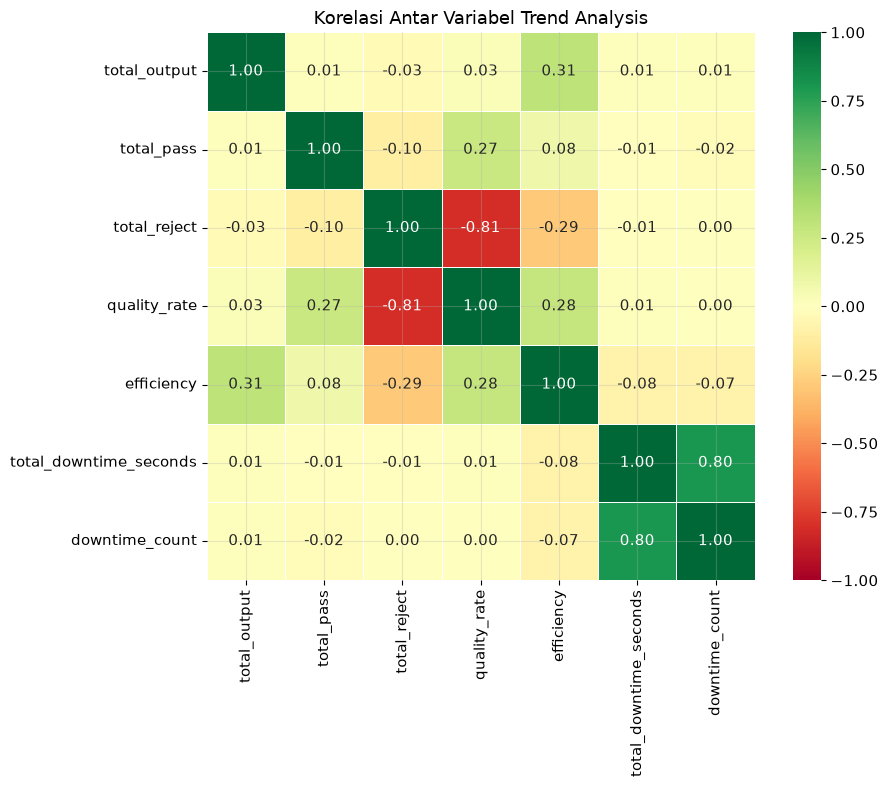

In [95]:
# Korelasi antar variabel di trend_analysis
trend_num_cols = ['total_output', 'total_pass', 'total_reject',
                  'quality_rate', 'efficiency', 'total_downtime_seconds', 'downtime_count']
trend_corr = trend[trend_num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(trend_corr, dtype=bool), k=1)
sns.heatmap(trend_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Korelasi Antar Variabel Trend Analysis')
plt.tight_layout()
plt.show()

📊 Rata-rata Metrik per Shift:
            total_output  quality_rate  efficiency  downtime_hours
shift_name                                                        
Shift 1         875.9550        0.9590      0.6630          0.2680
Shift 2         875.4070        0.9620      0.6620          0.2680
Shift 3         873.2080        0.9530      0.6550          0.2740


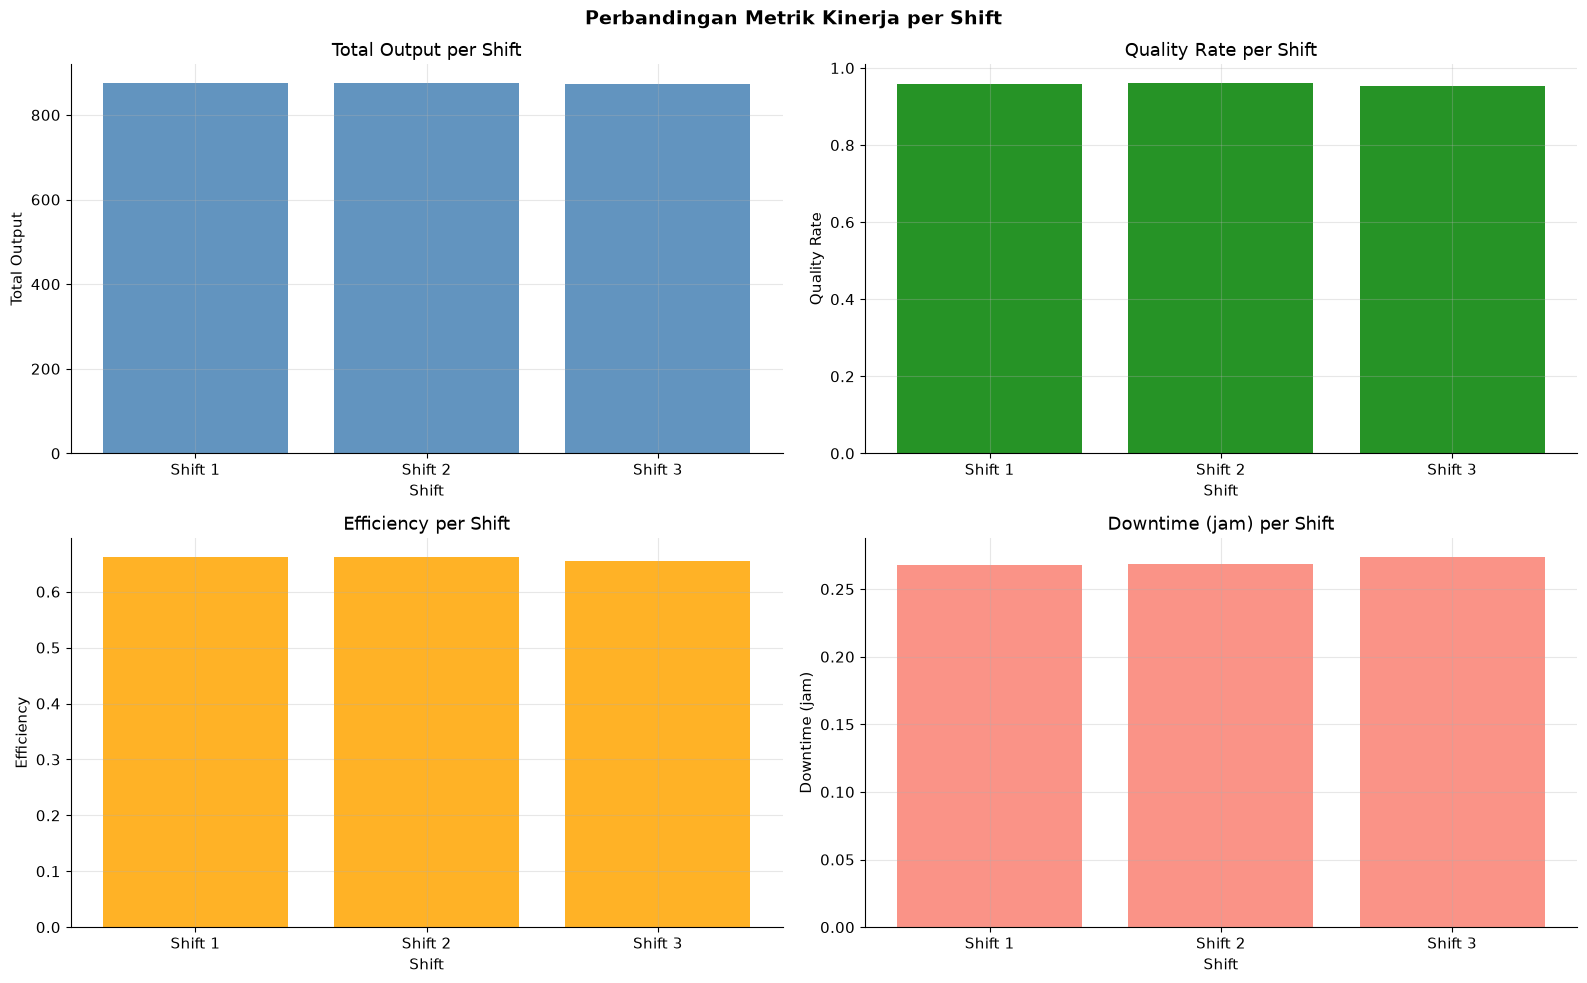

In [96]:
# Analisis berdasarkan shift
shift_map = dfs['shift'].set_index('id')['shift_name'].to_dict()
trend['shift_name'] = trend['shift_id'].map(shift_map)

print('📊 Rata-rata Metrik per Shift:')
shift_metrics = trend.groupby('shift_name')[[
    'total_output', 'quality_rate', 'efficiency', 'downtime_hours'
]].mean().round(3)
print(shift_metrics.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_shift = [
    ('total_output',   'Total Output',   'steelblue'),
    ('quality_rate',   'Quality Rate',   'green'),
    ('efficiency',     'Efficiency',     'orange'),
    ('downtime_hours', 'Downtime (jam)', 'salmon'),
]

for ax, (col, label, color) in zip(axes.flat, metrics_shift):
    data = trend.groupby('shift_name')[col].mean()
    ax.bar(data.index, data.values, color=color, alpha=0.85)
    ax.set_title(f'{label} per Shift')
    ax.set_xlabel('Shift')
    ax.set_ylabel(label)

plt.suptitle('Perbandingan Metrik Kinerja per Shift', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🤖 11. Feature Engineering — Persiapan untuk AI Model

In [97]:
# ── Gabungkan Dataset Utama untuk Model ───────────────────────────────────────

# Base: trend_analysis (data terlengkap per shift per line per proses)
df_model = trend.copy()

# Tambahkan data OEE
oee_merge = oee[[
    'line_id', 'line_process_id', 'shift_id',
    'oee_line', 'availability', 'perfomance', 'quality'
]].groupby(['line_id', 'line_process_id', 'shift_id']).mean().reset_index()

df_model = df_model.merge(
    oee_merge, on=['line_id', 'line_process_id', 'shift_id'], how='left'
)

# Tambahkan throughput machine
tp_merge = (
    tp_m[
        ['line_id', 'line_process_id', 'shift_id', 'troughput']
    ]
    .groupby(
        ['line_id', 'line_process_id', 'shift_id'],
        as_index=False
    )['troughput']
    .mean()
)

df_model = df_model.merge(
    tp_merge[['line_id', 'line_process_id', 'shift_id', 'troughput']],
    on=['line_id', 'line_process_id', 'shift_id'], how='left'
)

print(f'✅ Dataset gabungan: {df_model.shape[0]:,} rows × {df_model.shape[1]} kolom')
print(f'\nKolom yang tersedia:')
for col in df_model.columns:
    print(f'  · {col} ({df_model[col].dtype})')

✅ Dataset gabungan: 6,340 rows × 25 kolom

Kolom yang tersedia:
  · id (str)
  · line_id (str)
  · line_process_id (str)
  · shift_id (str)
  · recorded_date (datetime64[us])
  · recorded_hour (int64)
  · total_output (int64)
  · total_pass (int64)
  · total_reject (int64)
  · quality_rate (float64)
  · efficiency (float64)
  · total_downtime_seconds (int64)
  · downtime_count (int64)
  · planned_time_seconds (int64)
  · created_at (str)
  · updated_at (str)
  · line_name (str)
  · downtime_hours (float64)
  · downtime_rate (float64)
  · shift_name (str)
  · oee_line (float64)
  · availability (float64)
  · perfomance (float64)
  · quality (float64)
  · troughput (float64)


In [98]:
# ── Ekstraksi Fitur Waktu ─────────────────────────────────────────────────────
df_model['day_of_week']   = df_model['recorded_date'].dt.dayofweek   # 0=Mon … 6=Sun
df_model['week_of_year']  = df_model['recorded_date'].dt.isocalendar().week.astype(int)
df_model['month']         = df_model['recorded_date'].dt.month
df_model['is_weekend']    = df_model['day_of_week'].isin([5, 6]).astype(int)
df_model['shift_num']     = df_model['shift_name'].map(
    {'Shift 1': 1, 'Shift 2': 2, 'Shift 3': 3}
)

# ── Fitur Kualitas & Efisiensi ────────────────────────────────────────────────
df_model['reject_rate']    = df_model['total_reject'] / df_model['total_output'].replace(0, np.nan)
df_model['pass_rate']      = df_model['total_pass']   / df_model['total_output'].replace(0, np.nan)
df_model['downtime_rate']  = df_model['total_downtime_seconds'] / df_model['planned_time_seconds']
df_model['avg_sec_per_unit'] = df_model['planned_time_seconds'] / df_model['total_output'].replace(0, np.nan)

# ── Encode Kategorikal ────────────────────────────────────────────────────────
df_model['line_code'] = df_model['line_name'].str.extract(r'Line ([A-D])').iloc[:, 0]
line_code_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
df_model['line_encoded'] = df_model['line_code'].map(line_code_map)

print('✅ Feature engineering selesai!')
print(f'   Total fitur baru: {df_model.shape[1]} kolom')
df_model[['recorded_date', 'line_name', 'shift_name', 'total_output',
           'reject_rate', 'pass_rate', 'downtime_rate', 'efficiency',
           'oee_line', 'is_weekend', 'shift_num', 'day_of_week']].head(10)

✅ Feature engineering selesai!
   Total fitur baru: 35 kolom


,recorded_date,line_name,shift_name,total_output,reject_rate,pass_rate,downtime_rate,efficiency,oee_line,is_weekend,shift_num,day_of_week
0,2026-02-01,Line A,Shift 1,850,0.0000,0.0047,0.0000,0.6635,0.7269,1,1,6
1,2026-02-01,Line A,Shift 2,894,0.0000,0.0056,0.0000,0.6249,0.7262,1,2,6
2,2026-02-02,Line A,Shift 3,1050,0.0000,0.0038,0.0000,0.4120,0.7158,0,3,0
3,2026-02-01,Line A,Shift 1,700,0.0000,0.0071,0.0000,0.8529,0.5805,1,1,6
4,2026-02-01,Line A,Shift 2,925,0.0011,0.0022,0.0000,0.4722,0.6099,1,2,6
5,2026-02-02,Line A,Shift 3,680,0.0000,0.0059,0.0000,0.5072,0.5725,0,3,0
6,2026-02-01,Line A,Shift 1,992,0.0000,0.0040,0.0000,0.7082,0.7152,1,1,6
7,2026-02-01,Line A,Shift 2,907,0.0022,0.0044,0.0000,0.6667,0.7072,1,2,6
8,2026-02-02,Line A,Shift 3,915,0.0000,0.0033,0.0609,0.9391,0.6954,0,3,0
9,2026-02-01,Line B,Shift 1,977,0.0000,0.0041,0.0000,0.9658,0.6607,1,1,6


In [99]:
# ── Pilih Fitur Final untuk AI Model ─────────────────────────────────────────
FEATURE_COLS = [
    # Fitur Waktu
    'recorded_hour', 'day_of_week', 'week_of_year', 'month',
    'is_weekend', 'shift_num',
    # Identitas
    'line_encoded',
    # Produksi
    'total_output', 'total_pass', 'total_reject',
    'reject_rate', 'pass_rate', 'downtime_rate',
    'avg_sec_per_unit',
    # OEE Components
    'availability', 'perfomance', 'quality',
    # Downtime
    'total_downtime_seconds', 'downtime_count',
    # Throughput
    'troughput',
]

# Target variabel potensial:
TARGET_COLS = {
    'oee_prediction'     : 'oee_line',          # → Prediksi OEE (Regression)
    'output_forecast'    : 'total_output',       # → Forecast output (Time-series)
    'reject_prediction'  : 'total_reject',       # → Prediksi reject (Regression)
    'efficiency_forecast': 'efficiency',         # → Prediksi efisiensi
}

print('🎯 FITUR UNTUK AI MODEL')
print(f'  Feature columns  : {len(FEATURE_COLS)}')
print(f'  Target variables : {len(TARGET_COLS)}')
print('\n  Features:')
for f in FEATURE_COLS:
    print(f'    · {f}')
print('\n  Targets (pilih salah satu sesuai use case):')
for use_case, col in TARGET_COLS.items():
    print(f'    · [{use_case}] → kolom: "{col}"')

🎯 FITUR UNTUK AI MODEL
  Feature columns  : 20
  Target variables : 4

  Features:
    · recorded_hour
    · day_of_week
    · week_of_year
    · month
    · is_weekend
    · shift_num
    · line_encoded
    · total_output
    · total_pass
    · total_reject
    · reject_rate
    · pass_rate
    · downtime_rate
    · avg_sec_per_unit
    · availability
    · perfomance
    · quality
    · total_downtime_seconds
    · downtime_count
    · troughput

  Targets (pilih salah satu sesuai use case):
    · [oee_prediction] → kolom: "oee_line"
    · [output_forecast] → kolom: "total_output"
    · [reject_prediction] → kolom: "total_reject"
    · [efficiency_forecast] → kolom: "efficiency"


In [100]:
# ── Cek Missing Values di Dataset Final ──────────────────────────────────────
all_cols = FEATURE_COLS + list(TARGET_COLS.values())
df_final = df_model[['recorded_date', 'line_name', 'shift_name'] + all_cols].copy()

null_check = df_final.isnull().sum().sort_values(ascending=False)
null_pct   = (df_final.isnull().mean() * 100).sort_values(ascending=False)

null_df = pd.DataFrame({'null_count': null_check, 'null_%': null_pct})
null_df = null_df[null_df['null_count'] > 0]

if null_df.empty:
    print('✅ Tidak ada missing values di dataset final!')
else:
    print('⚠️  Missing values ditemukan:')
    print(null_df.to_string())
    # Isi missing dengan median
    for col in null_df.index:
        if df_final[col].dtype in ['float64', 'int64']:
            df_final[col].fillna(df_final[col].median(), inplace=True)
    print('\n✅ Missing values telah diisi dengan median.')

print(f'\n📐 Shape dataset final: {df_final.shape}')
df_final.head(5)

✅ Tidak ada missing values di dataset final!

📐 Shape dataset final: (6340, 27)


,recorded_date,line_name,shift_name,recorded_hour,day_of_week,week_of_year,month,is_weekend,shift_num,line_encoded,total_output,total_pass,total_reject,reject_rate,pass_rate,downtime_rate,avg_sec_per_unit,availability,perfomance,quality,total_downtime_seconds,downtime_count,troughput,oee_line,total_output,total_reject,efficiency
0,2026-02-01,Line A,Shift 1,6,6,5,2,1,1,0,850,4,0,0.0000,0.0047,0.0000,33.8824,0.9715,0.7812,0.9603,0,0,126.6647,0.7269,850,0,0.6635
1,2026-02-01,Line A,Shift 2,14,6,5,2,1,2,0,894,5,0,0.0000,0.0056,0.0000,32.2148,0.9732,0.7721,0.9673,0,0,126.5353,0.7262,894,0,0.6249
2,2026-02-02,Line A,Shift 3,22,0,6,2,0,3,0,1050,4,0,0.0000,0.0038,0.0000,27.4286,0.9726,0.7704,0.9544,0,0,128.1518,0.7158,1050,0,0.4120
3,2026-02-01,Line A,Shift 1,6,6,5,2,1,1,0,700,5,0,0.0000,0.0071,0.0000,41.1429,0.9580,0.6420,0.9496,0,0,99.0782,0.5805,700,0,0.8529
4,2026-02-01,Line A,Shift 2,14,6,5,2,1,2,0,925,2,1,0.0011,0.0022,0.0000,31.1351,0.9596,0.6537,0.9768,0,0,99.8704,0.6099,925,1,0.4722


---
## 💾 12. Simpan Dataset Siap Pakai untuk AI Model

In [101]:
import os

# Buat folder output jika belum ada
OUTPUT_DIR = os.path.join('..', 'dataset', 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Simpan dataset gabungan lengkap
path_full = os.path.join(OUTPUT_DIR, 'df_model_full.csv')
df_final.to_csv(path_full, index=False)
print(f'✅ Dataset lengkap tersimpan  : {path_full}')
print(f'   Shape                      : {df_final.shape}')

# Simpan per use case (hanya fitur + 1 target)
for use_case, target_col in TARGET_COLS.items():
    cols_to_save = FEATURE_COLS + [target_col]
    # Hanya kolom yang ada
    cols_to_save = [c for c in cols_to_save if c in df_final.columns]
    df_uc = df_final[cols_to_save].dropna()
    path_uc = os.path.join(OUTPUT_DIR, f'df_{use_case}.csv')
    df_uc.to_csv(path_uc, index=False)
    print(f'✅ [{use_case}]  → {path_uc}  ({df_uc.shape})')

# Simpan juga semua tabel master sebagai CSV
for name in ['line', 'machine', 'process', 'shift', 'technician', 'pn']:
    path_m = os.path.join(OUTPUT_DIR, f'{name}.csv')
    dfs[name].to_csv(path_m, index=False)
    print(f'✅ Master [{name}] → {path_m}')

print('\n🎉 Semua file berhasil disimpan!')

✅ Dataset lengkap tersimpan  : ..\dataset\processed\df_model_full.csv
   Shape                      : (6340, 27)
✅ [oee_prediction]  → ..\dataset\processed\df_oee_prediction.csv  ((6340, 23))
✅ [output_forecast]  → ..\dataset\processed\df_output_forecast.csv  ((6340, 24))
✅ [reject_prediction]  → ..\dataset\processed\df_reject_prediction.csv  ((6340, 24))
✅ [efficiency_forecast]  → ..\dataset\processed\df_efficiency_forecast.csv  ((6340, 23))
✅ Master [line] → ..\dataset\processed\line.csv
✅ Master [machine] → ..\dataset\processed\machine.csv
✅ Master [process] → ..\dataset\processed\process.csv
✅ Master [shift] → ..\dataset\processed\shift.csv
✅ Master [technician] → ..\dataset\processed\technician.csv
✅ Master [pn] → ..\dataset\processed\pn.csv

🎉 Semua file berhasil disimpan!


---
## 📋 13. Ringkasan & Insight untuk AI Model

In [102]:
print('=' * 70)
print('  RINGKASAN DATASET PT VOLEX MMS PRODUCTION')
print('=' * 70)

print(f'''
📌 OVERVIEW DATASET
  • Total sheet/tabel    : {len(DATA_SHEETS)}
  • Periode data         : Feb 2026 – Aug 2026 (~6 bulan)
  • Total baris utama    : {df_final.shape[0]:,} records
  • Fitur tersedia       : {len(FEATURE_COLS)} features
  • Target variabel      : {len(TARGET_COLS)} use cases

📌 METRIK KINERJA RATA-RATA
  • OEE Overall          : {oee["oee_line"].mean()*100:.1f}%  (World-class: >85%)
  • Availability         : {oee["availability"].mean()*100:.1f}%
  • Performance          : {oee["perfomance"].mean()*100:.1f}%  ← Bottleneck utama
  • Quality              : {oee["quality"].mean()*100:.1f}%
  • Actual Output        : {ao["output"].mean():.0f} / {ao["target_output"].iloc[0]} unit ({ao["output"].mean()/ao["target_output"].iloc[0]*100:.1f}%)
  • Reject Rate          : {defect["reject_rate"].mean()*100:.2f}%
  • Avg Throughput       : {tp_m["troughput"].mean():.1f} unit/jam
  • Avg Cycle Time       : {ct_m["actual_cycle_time"].mean():.1f} detik/unit

📌 AI MODEL YANG DAPAT DIBUAT
  1. OEE Prediction      → Regression → Target: oee_line
  2. Output Forecasting  → Time-series → Target: total_output
  3. Reject Prediction   → Regression → Target: total_reject
  4. Efficiency Forecast → Regression → Target: efficiency
  5. Predictive Maint.   → Anomaly Detection → dari machine_status_log
  6. WO Classification   → Multi-class → Target: work_order.type

📌 CATATAN PENTING
  • "perfomance" (typo, harusnya performance) — sudah dipetakan
  • "troughput" (typo, harusnya throughput) — sudah dipetakan
  • 74 WO belum completed (completed_at = null) — normal untuk WO aktif
  • machine_status_log.data = 100% null — kolom ini bisa dibuang
  • target_output selalu 1000 — konstan, bukan fitur prediktif
  • planned_time_seconds selalu 28800 — konstan (8 jam/shift)
''')

print('=' * 70)
print('  DATASET SIAP DIGUNAKAN UNTUK AI MODEL!')
print('  File tersimpan di: dataset/processed/')
print('=' * 70)

  RINGKASAN DATASET PT VOLEX MMS PRODUCTION

📌 OVERVIEW DATASET
  • Total sheet/tabel    : 24
  • Periode data         : Feb 2026 – Aug 2026 (~6 bulan)
  • Total baris utama    : 6,340 records
  • Fitur tersedia       : 20 features
  • Target variabel      : 4 use cases

📌 METRIK KINERJA RATA-RATA
  • OEE Overall          : 66.0%  (World-class: >85%)
  • Availability         : 96.6%
  • Performance          : 71.3%  ← Bottleneck utama
  • Quality              : 96.0%
  • Actual Output        : 875 / 1000 unit (87.5%)
  • Reject Rate          : 3.97%
  • Avg Throughput       : 113.8 unit/jam
  • Avg Cycle Time       : 28.3 detik/unit

📌 AI MODEL YANG DAPAT DIBUAT
  1. OEE Prediction      → Regression → Target: oee_line
  2. Output Forecasting  → Time-series → Target: total_output
  3. Reject Prediction   → Regression → Target: total_reject
  4. Efficiency Forecast → Regression → Target: efficiency
  5. Predictive Maint.   → Anomaly Detection → dari machine_status_log
  6. WO Classificat